# 1. **Importing the dependencies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score,precision_recall_curve, average_precision_score,recall_score,f1_score,precision_score
import pickle

# 2. **Loading and understanding the data**





In [ ]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#drop customer_id column as it is not necessary for modeling
df.drop(columns=["customerID"],inplace=True)

In [ ]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [ ]:
#printing and understanding unique values in each categorical column to understand the next encoding step
numerical_columns=["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
  if col not in numerical_columns:
    print(col,df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [ ]:
#TotalCharges is in object type,we need to convert to float value

#df["TotalCharges"]=df["TotalCharges"].astype(float)
#This line of code gives an error as there are empty spaces in the TotalCharges column
#On verification, the total charges are empty where the tenure of the user is 0 months

In [ ]:
len(df[df["TotalCharges"]==" "])

11

In [ ]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0.0")
#replace as string as the other values are in string

In [ ]:
df["TotalCharges"]=df["TotalCharges"].astype(float)
#now we can convert to float

In [ ]:
df["Churn"].value_counts()
#we see a major imbalance here

,count
Churn,
No,5174
Yes,1869


***INSIGHTS***

1. We removed customer_id as it was not required for modeling
2. No missing values in the dataset
3. Missing values in totalcharges were replaced with 0
4. Class imbalance identified in the target(churn)

# 3. **EDA**

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


*3A) Numerical features - Analysis*

*   Histogram
*   Box Plot
*   Correlation Heatmap



In [ ]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)
  plt.title(f"Distribution of {column_name}")
  #calculate mean and median for the columns
  col_mean=df[column_name].mean()
  col_median=df[column_name].median()
  #add vertical lines for mean and median
  plt.axvline(col_mean,color="red",linestyle="--",label="Mean")
  plt.axvline(col_median,color="green",linestyle="-",label="Median")
  plt.legend()
  plt.show()


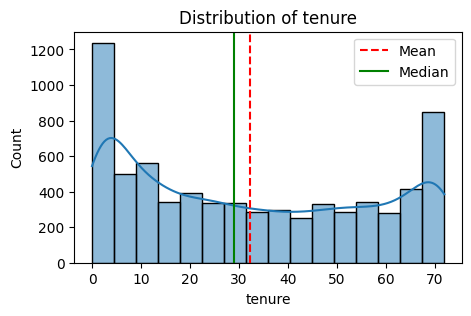

In [ ]:
plot_histogram(df,"tenure")
#not normally distributed

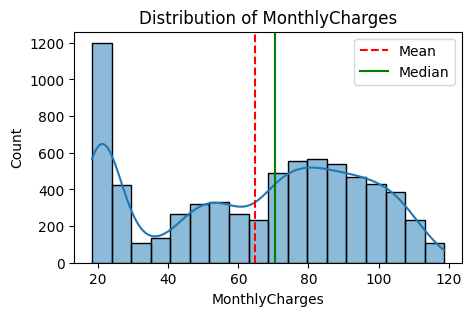

In [ ]:
plot_histogram(df,"MonthlyCharges")
#not normally distributed

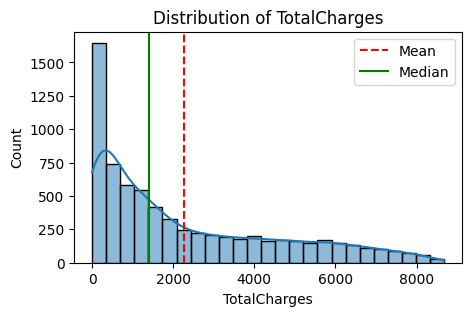

In [ ]:
plot_histogram(df,"TotalCharges")
#right skewed

In [ ]:
def plot_boxplot(df,column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()


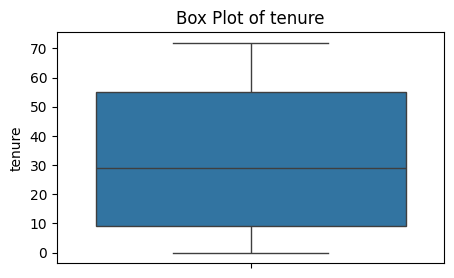

In [ ]:
plot_boxplot(df,"tenure")

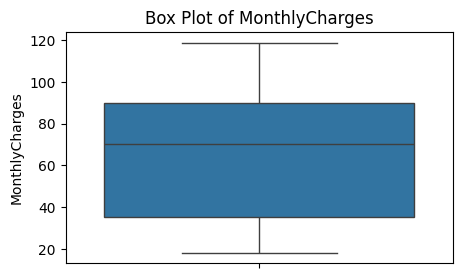

In [ ]:
plot_boxplot(df,"MonthlyCharges")

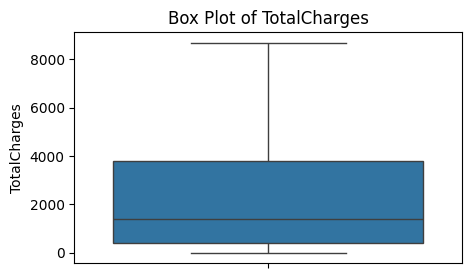

In [ ]:
plot_boxplot(df,"TotalCharges")

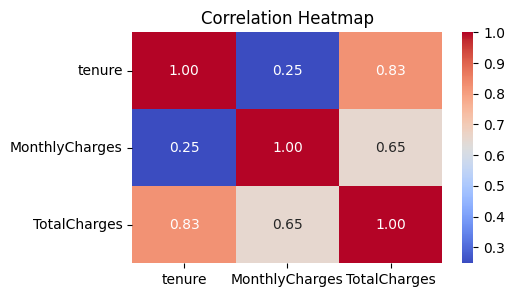

In [ ]:
plt.figure(figsize= (5,3))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
#if we have more than 2 combos highly correlated, we eliminate one, to prevent multi colllinearity

*INFERENCES*


1.   The histograms show data to be right skewed and not normally distributed - we can perform standardization.
2.   The box plots concur with the data interpretation
3.   The correlation heatmap does not show multiple highly correlated columns. If it did, we would eliminate one or more in order to prevent multi-collinearity.



*3B) CATEGORICAL COLUMNS*

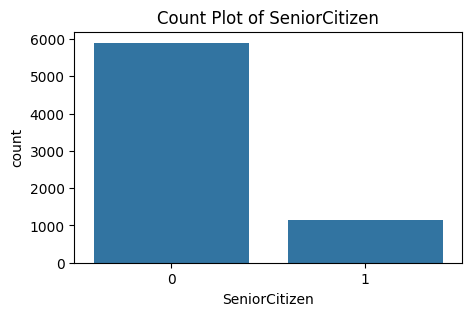

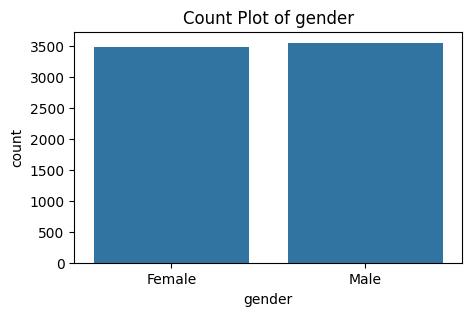

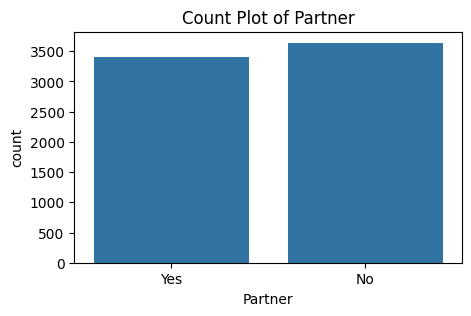

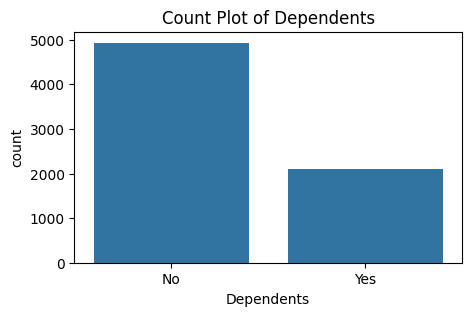

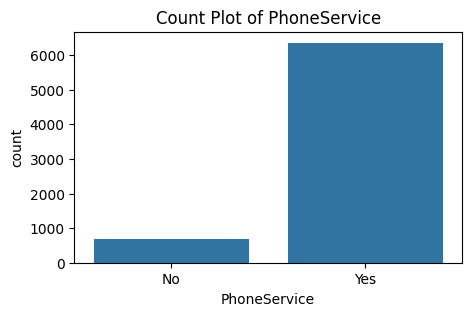

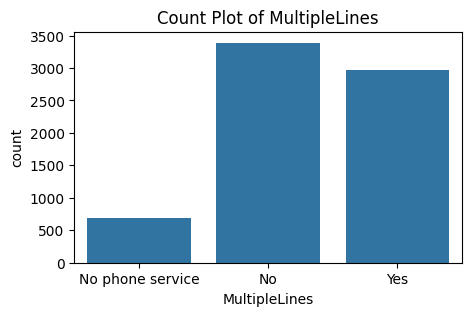

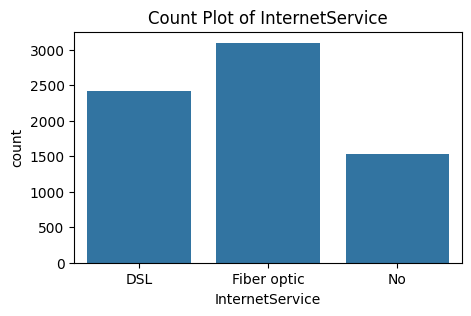

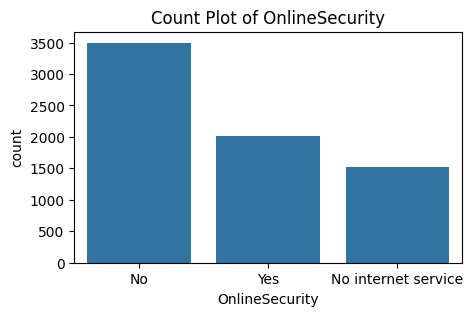

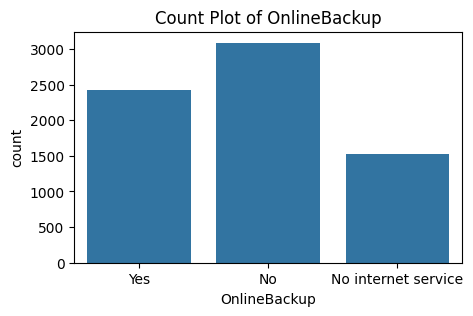

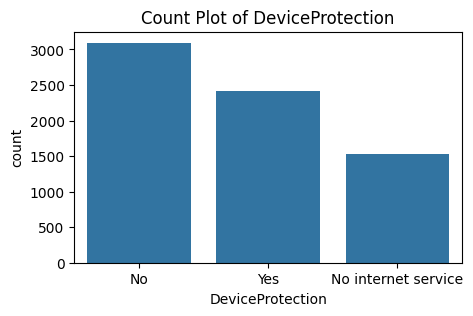

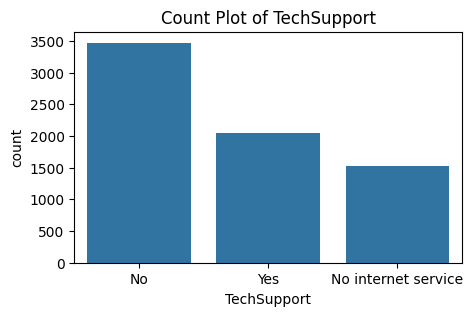

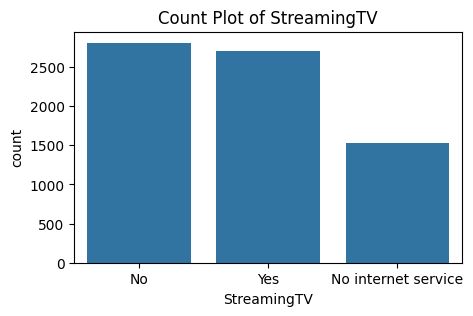

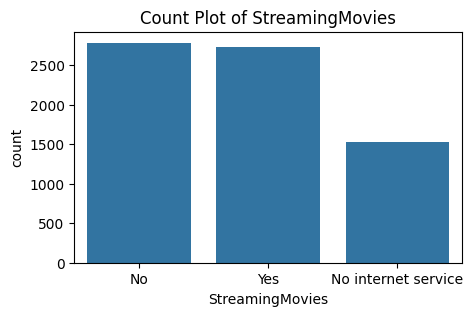

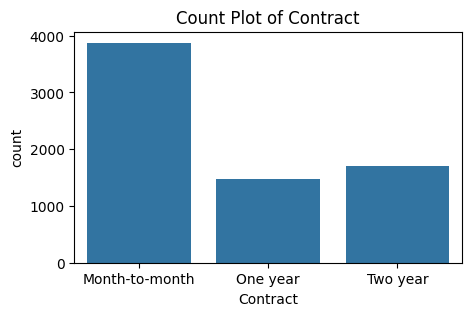

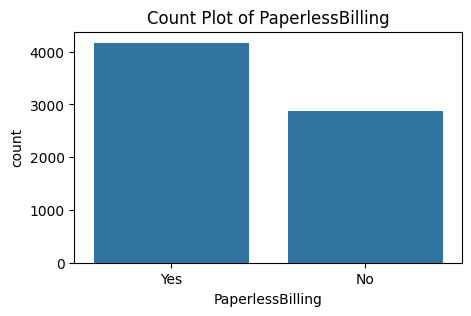

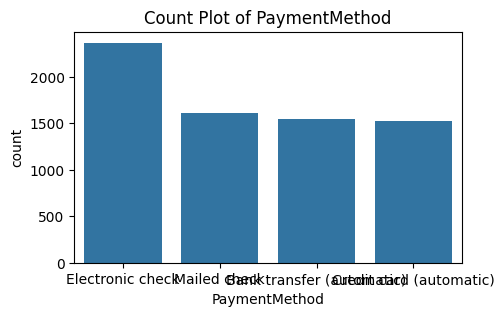

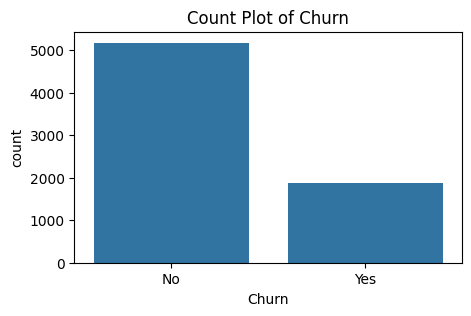

In [ ]:
#COUNT PLOT
# First get object columns as a list
object_cols_list = df.select_dtypes(include="object").columns.tolist()

# Then, prepend 'SeniorCitizen' to this list
# SeniorCitizen is an int64 type, but treated as categorical here (0 or 1)
all_categorical_cols = ["SeniorCitizen"] + object_cols_list

for col in all_categorical_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

*INFERENCES*


1.   There appears to be somewhat skewed distribution of data
2.   We give more importance to the target column churn as it has most imbalance abd would lead to complications for the model trained.



# **4. DATA PREPROCESSING**

In [ ]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# feature encoding the target column
df["Churn"] = df["Churn"].replace({"No":0,"Yes":1})

/tmp/ipykernel_451/400993166.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"No":0,"Yes":1})


In [ ]:
df["Churn"]

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
# Performing train-test-split
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


*4A) FEATURE ENCODING*

In [ ]:
# Define categorical and numerical columns for transformation
# Note: 'SeniorCitizen' is already numerical (0/1) but behaves categorically, so it's not included in one-hot encoding here.

categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
# Include 'tenure' for standardization as per previous discussion
numerical_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']

# Create a ColumnTransformer
trf1 = ColumnTransformer([
    ('ohe_cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('scale_num', StandardScaler(), numerical_cols)
], remainder='passthrough') # 'remainder=passthrough' keeps other columns like 'SeniorCitizen'

# Fit and transform training data
X_train_transformed = trf1.fit_transform(X_train)

# Transform test data
X_test_transformed = trf1.transform(X_test)

print(f"Shape of X_train_transformed: {X_train_transformed.shape}")
print(f"Shape of X_test_transformed: {X_test_transformed.shape}")

Shape of X_train_transformed: (5634, 45)
Shape of X_test_transformed: (1409, 45)


In [ ]:
# Define categorical and numerical columns for the ColumnTransformer within the pipeline
categorical_cols_pipeline = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
numerical_cols_pipeline = ['MonthlyCharges', 'TotalCharges', 'tenure']

# Create a ColumnTransformer for the pipeline
preprocessor_pipeline = ColumnTransformer([
    ('ohe_cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_pipeline),
    ('scale_num', StandardScaler(), numerical_cols_pipeline)
], remainder='passthrough')

# **5. MODEL TRAINING USING SMOTE**

#### 5A) Training and Evaluating Logistic Regression Model (with SMOTE)

In [ ]:
# Create the imbalanced-learn pipeline for Logistic Regression using SMOTE
lr_pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    ('smote', SMOTE(random_state=42)), # Using default sampling_strategy=1.0
    ('logisticregression', LogisticRegression(solver='liblinear', random_state=42)) # Using default C=1.0
])

# Fit the Logistic Regression pipeline with SMOTE
print("Training Logistic Regression Classifier with SMOTE...")
lr_pipeline_smote.fit(X_train, y_train)
print("Logistic Regression Classifier with SMOTE trained.")

# Make predictions on the test set
y_pred_lr_smote = lr_pipeline_smote.predict(X_test)

# Evaluate the Logistic Regression model with SMOTE
print("\nLogistic Regression Classifier Performance on Test Set (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_smote):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_smote))

# Also print individual scores for clarity
print(f"\nPrecision for Churn (1): {precision_score(y_test, y_pred_lr_smote):.4f}")
print(f"Recall for Churn (1): {recall_score(y_test, y_pred_lr_smote):.4f}")
print(f"F1-Score for Churn (1): {f1_score(y_test, y_pred_lr_smote):.4f}")

Training Logistic Regression Classifier with SMOTE...
Logistic Regression Classifier with SMOTE trained.

Logistic Regression Classifier Performance on Test Set (with SMOTE):
Accuracy: 0.7381

Confusion Matrix:
 [[743 292]
 [ 77 297]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Precision for Churn (1): 0.5042
Recall for Churn (1): 0.7941
F1-Score for Churn (1): 0.6168


#### 5B) Training and Evaluating Random Forest Classifier (with SMOTE and Class Weights)

In [ ]:
# Create the imbalanced-learn pipeline for Random Forest
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    # Using standard SMOTE parameters (sampling_strategy defaults to 1.0)
    ('smote', SMOTE(random_state=42)),
    # Using standard RandomForest n_estimators (defaults to 100)
    ('randomforest', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Fit the Random Forest pipeline
print("Training Random Forest Classifier with class_weight='balanced' and standard SMOTE parameters...")
rf_pipeline.fit(X_train, y_train)
print("Random Forest Classifier trained.")

# Get predicted probabilities for the positive class (churn=1)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Define a custom threshold (you can change this value)
custom_threshold_rf = 0.4 # Starting with 0.4

# Apply the custom threshold to get new binary predictions
y_pred_rf_thresh = (y_pred_proba_rf >= custom_threshold_rf).astype(int)

# Evaluate the Random Forest model with the custom threshold
print(f"\nRandom Forest Classifier Performance on Test Set (Standard SMOTE, class_weight='balanced', Threshold={custom_threshold_rf}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_thresh):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_thresh))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_thresh))

# Also print individual scores for clarity
print(f"\nPrecision for Churn (1): {precision_score(y_test, y_pred_rf_thresh):.4f}")
print(f"Recall for Churn (1): {recall_score(y_test, y_pred_rf_thresh):.4f}")
print(f"F1-Score for Churn (1): {f1_score(y_test, y_pred_rf_thresh):.4f}")

Training Random Forest Classifier with class_weight='balanced' and standard SMOTE parameters...
Random Forest Classifier trained.

Random Forest Classifier Performance on Test Set (Standard SMOTE, class_weight='balanced', Threshold=0.4):
Accuracy: 0.7551

Confusion Matrix:
 [[816 219]
 [126 248]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.53      0.66      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.76      1409


Precision for Churn (1): 0.5310
Recall for Churn (1): 0.6631
F1-Score for Churn (1): 0.5898


#### 5C) Training and Evaluating XGBoost Classifier (with SMOTE)

In [ ]:
# Create the imbalanced-learn pipeline for XGBoost using SMOTE
xgb_pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    ('smote', SMOTE(random_state=42)), # Using default sampling_strategy=1.0
    ('xgboost', XGBClassifier(random_state=42, eval_metric='logloss')) # Added eval_metric to suppress warning
])

# Fit the XGBoost pipeline with SMOTE
print("Training XGBoost Classifier with SMOTE...")
xgb_pipeline_smote.fit(X_train, y_train)
print("XGBoost Classifier with SMOTE trained.")

# Make predictions on the test set
y_pred_xgb_smote = xgb_pipeline_smote.predict(X_test)

# Evaluate the XGBoost model with SMOTE
print("\nXGBoost Classifier Performance on Test Set (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_smote):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_smote))

# Also print individual scores for clarity
print(f"\nPrecision for Churn (1): {precision_score(y_test, y_pred_xgb_smote):.4f}")
print(f"Recall for Churn (1): {recall_score(y_test, y_pred_xgb_smote):.4f}")
print(f"F1-Score for Churn (1): {f1_score(y_test, y_pred_xgb_smote):.4f}")

Training XGBoost Classifier with SMOTE...
XGBoost Classifier with SMOTE trained.

XGBoost Classifier Performance on Test Set (with SMOTE):
Accuracy: 0.7828

Confusion Matrix:
 [[879 156]
 [150 224]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Precision for Churn (1): 0.5895
Recall for Churn (1): 0.5989
F1-Score for Churn (1): 0.5942


# **6. MODEL TRAINING USING UNDERSAMPLING**

#### 6A) Training and Evaluating Logistic Regression (with Undersampling)

In [ ]:
    # Create the imbalanced-learn pipeline for Logistic Regression using RandomUnderSampler
lr_pipeline_undersample = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    ('undersampler', RandomUnderSampler(random_state=42, sampling_strategy=1.0)), # Undersampling
    ('logisticregression', LogisticRegression(solver='liblinear', random_state=42))
])

# Fit the Logistic Regression pipeline with undersampling
print("Training Logistic Regression Classifier with Undersampling...")
lr_pipeline_undersample.fit(X_train, y_train)
print("Logistic Regression Classifier with Undersampling trained.")

# Make predictions on the test set
y_pred_lr_undersample = lr_pipeline_undersample.predict(X_test)

# Evaluate the Logistic Regression model with undersampling
print("\nLogistic Regression Classifier Performance on Test Set (with Undersampling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_undersample):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_undersample))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_undersample))

Training Logistic Regression Classifier with Undersampling...
Logistic Regression Classifier with Undersampling trained.

Logistic Regression Classifier Performance on Test Set (with Undersampling):
Accuracy: 0.7424

Confusion Matrix:
 [[752 283]
 [ 80 294]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



#### 6B) Training and Evaluating Random Forest Classifier (with Standard Parameters on Undersampled Data)

In [ ]:
# Create the imbalanced-learn pipeline for Random Forest using RandomUnderSampler
rf_pipeline_undersample_standard = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    ('undersampler', RandomUnderSampler(random_state=42, sampling_strategy=1.0)), # Undersampling to balance classes
    ('randomforest', RandomForestClassifier(random_state=42)) # Standard parameters for Random Forest
])

# Fit the Random Forest pipeline with undersampling
print("Training Random Forest Classifier with standard parameters on Undersampled Data...")
rf_pipeline_undersample_standard.fit(X_train, y_train)
print("Random Forest Classifier with standard parameters on Undersampled Data trained.")

# Make predictions on the test set
y_pred_rf_undersample_standard = rf_pipeline_undersample_standard.predict(X_test)

# Evaluate the Random Forest model with undersampling and standard parameters
print("\nRandom Forest Classifier Performance on Test Set (Undersampled, Standard Params):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_undersample_standard):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_undersample_standard))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_undersample_standard))

# Also print individual scores for clarity
print(f"\nPrecision for Churn (1): {precision_score(y_test, y_pred_rf_undersample_standard):.4f}")
print(f"Recall for Churn (1): {recall_score(y_test, y_pred_rf_undersample_standard):.4f}")
print(f"F1-Score for Churn (1): {f1_score(y_test, y_pred_rf_undersample_standard):.4f}")

Training Random Forest Classifier with standard parameters on Undersampled Data...
Random Forest Classifier with standard parameters on Undersampled Data trained.

Random Forest Classifier Performance on Test Set (Undersampled, Standard Params):
Accuracy: 0.7452

Confusion Matrix:
 [[765 270]
 [ 89 285]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409


Precision for Churn (1): 0.5135
Recall for Churn (1): 0.7620
F1-Score for Churn (1): 0.6136


#### 6C) Training and Evaluating XGBoost Classifier (with Undersampling)

In [ ]:
# Create the imbalanced-learn pipeline for XGBoost using RandomUnderSampler
xgb_pipeline_undersample = ImbPipeline([
    ('preprocessor', preprocessor_pipeline),
    ('undersampler', RandomUnderSampler(random_state=42, sampling_strategy=1.0)), # Undersampling to balance classes
    ('xgboost', XGBClassifier(random_state=42, eval_metric='logloss')) # Added eval_metric to suppress warning
])

# Fit the XGBoost pipeline with undersampling
print("Training XGBoost Classifier with Undersampling...")
xgb_pipeline_undersample.fit(X_train, y_train)
print("XGBoost Classifier with Undersampling trained.")

# Make predictions on the test set
y_pred_xgb_undersample = xgb_pipeline_undersample.predict(X_test)

# Evaluate the XGBoost model with undersampling
print("\nXGBoost Classifier Performance on Test Set (with Undersampling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_undersample):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_undersample))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_undersample))

# Also print individual scores for clarity
print(f"\nPrecision for Churn (1): {precision_score(y_test, y_pred_xgb_undersample):.4f}")
print(f"Recall for Churn (1): {recall_score(y_test, y_pred_xgb_undersample):.4f}")
print(f"F1-Score for Churn (1): {f1_score(y_test, y_pred_xgb_undersample):.4f}")

Training XGBoost Classifier with Undersampling...
XGBoost Classifier with Undersampling trained.

XGBoost Classifier Performance on Test Set (with Undersampling):
Accuracy: 0.7317

Confusion Matrix:
 [[746 289]
 [ 89 285]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.72      0.80      1035
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409


Precision for Churn (1): 0.4965
Recall for Churn (1): 0.7620
F1-Score for Churn (1): 0.6013


 # 7. **Evaluation metrics - ROC curve, AUC scores, Precision-Recall Curve and finding Feature Importance**

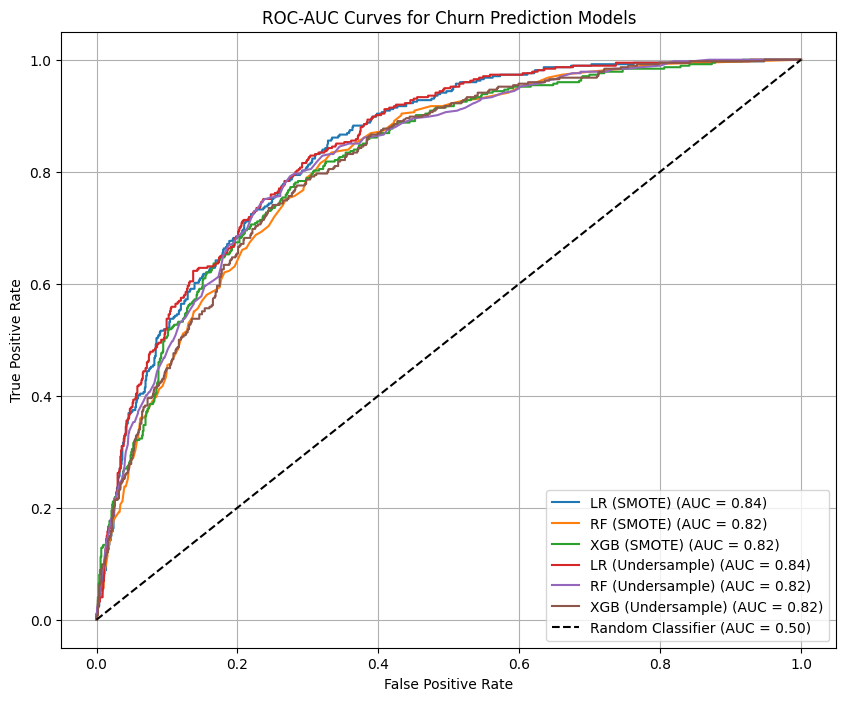

In [ ]:
# Get predicted probabilities for all models

y_pred_proba_lr_smote = lr_pipeline_smote.predict_proba(X_test)[:, 1]
y_pred_proba_xgb_smote = xgb_pipeline_smote.predict_proba(X_test)[:, 1]
y_pred_proba_lr_undersample = lr_pipeline_undersample.predict_proba(X_test)[:, 1]
y_pred_proba_rf_undersample_standard = rf_pipeline_undersample_standard.predict_proba(X_test)[:, 1]
y_pred_proba_xgb_undersample = xgb_pipeline_undersample.predict_proba(X_test)[:, 1]

# Calculate ROC curves and AUC scores

# Logistic Regression with SMOTE
fpr_lr_smote, tpr_lr_smote, _ = roc_curve(y_test, y_pred_proba_lr_smote)
auc_lr_smote = roc_auc_score(y_test, y_pred_proba_lr_smote)

# Random Forest with SMOTE (using existing probabilities)
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, y_pred_proba_rf) # y_pred_proba_rf was generated earlier
auc_rf_smote = roc_auc_score(y_test, y_pred_proba_rf)

# XGBoost with SMOTE
fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_pred_proba_xgb_smote)
auc_xgb_smote = roc_auc_score(y_test, y_pred_proba_xgb_smote)

# Logistic Regression with Undersampling
fpr_lr_undersample, tpr_lr_undersample, _ = roc_curve(y_test, y_pred_proba_lr_undersample)
auc_lr_undersample = roc_auc_score(y_test, y_pred_proba_lr_undersample)

# Random Forest with Undersampling
fpr_rf_undersample_standard, tpr_rf_undersample_standard, _ = roc_curve(y_test, y_pred_proba_rf_undersample_standard)
auc_rf_undersample_standard = roc_auc_score(y_test, y_pred_proba_rf_undersample_standard)

# XGBoost with Undersampling
fpr_xgb_undersample, tpr_xgb_undersample, _ = roc_curve(y_test, y_pred_proba_xgb_undersample)
auc_xgb_undersample = roc_auc_score(y_test, y_pred_proba_xgb_undersample)

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr_smote, tpr_lr_smote, label=f'LR (SMOTE) (AUC = {auc_lr_smote:.2f})')
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f'RF (SMOTE) (AUC = {auc_rf_smote:.2f})')
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f'XGB (SMOTE) (AUC = {auc_xgb_smote:.2f})')
plt.plot(fpr_lr_undersample, tpr_lr_undersample, label=f'LR (Undersample) (AUC = {auc_lr_undersample:.2f})')
plt.plot(fpr_rf_undersample_standard, tpr_rf_undersample_standard, label=f'RF (Undersample) (AUC = {auc_rf_undersample_standard:.2f})')
plt.plot(fpr_xgb_undersample, tpr_xgb_undersample, label=f'XGB (Undersample) (AUC = {auc_xgb_undersample:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for Churn Prediction Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

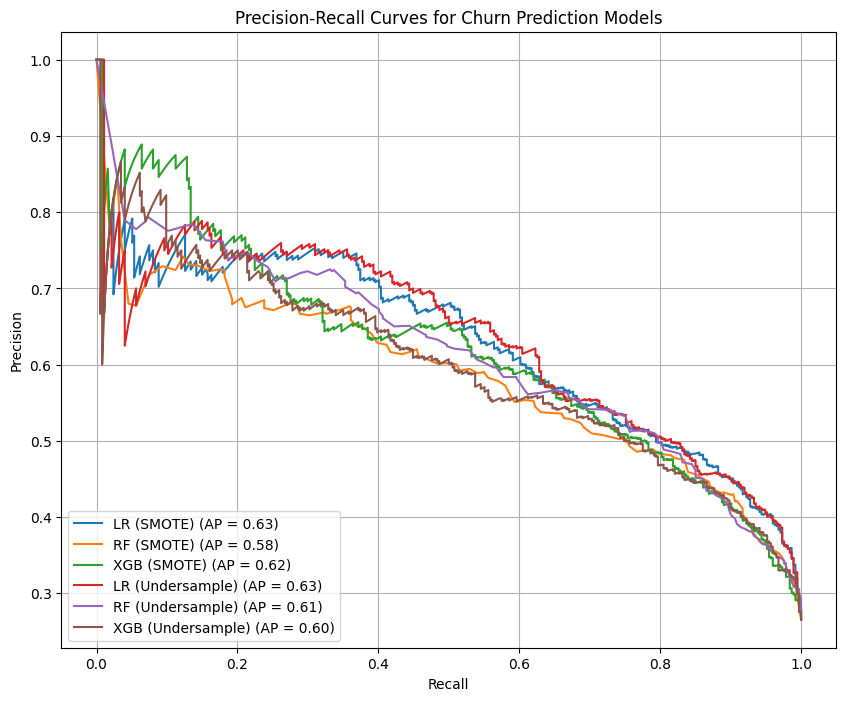

In [ ]:
# Predicted probabilities are already available from the previous cell (e651d8a7)
# y_pred_proba_lr_smote, y_pred_proba_rf_smote, y_pred_proba_xgb_smote,
# y_pred_proba_lr_undersample, y_pred_proba_rf_undersample_standard, y_pred_proba_xgb_undersample

plt.figure(figsize=(10, 8))

models_proba = {
    'LR (SMOTE)': y_pred_proba_lr_smote,
    'RF (SMOTE)': y_pred_proba_rf,
    'XGB (SMOTE)': y_pred_proba_xgb_smote,
    'LR (Undersample)': y_pred_proba_lr_undersample,
    'RF (Undersample)': y_pred_proba_rf_undersample_standard,
    'XGB (Undersample)': y_pred_proba_xgb_undersample
}

for name, y_proba in models_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Churn Prediction Models')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

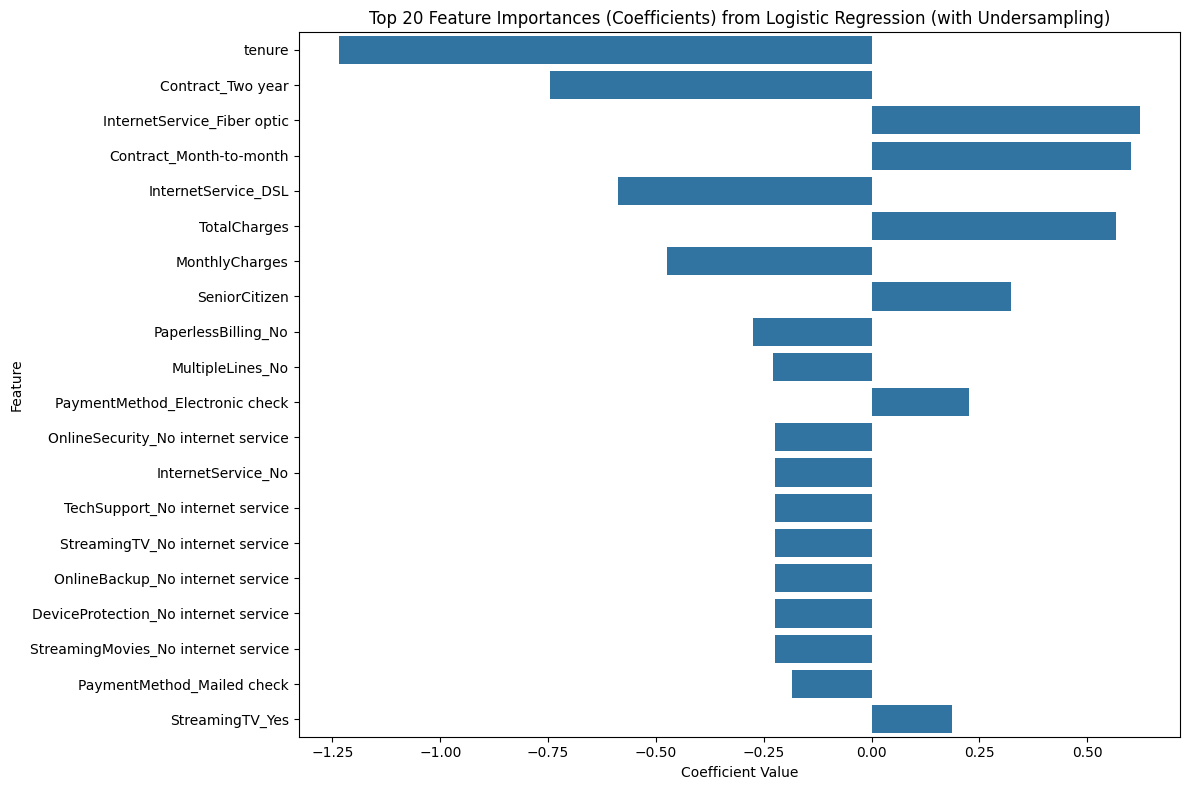

In [ ]:
# Get the trained Logistic Regression model from the pipeline
log_reg_model = lr_pipeline_undersample.named_steps['logisticregression']

# Reconstruct feature names from the ColumnTransformer
# 1. Get names from OneHotEncoder
ohe_feature_names_lr = lr_pipeline_undersample.named_steps['preprocessor'].named_transformers_['ohe_cat'].get_feature_names_out(categorical_cols_pipeline)

# 2. Get names from StandardScaler (these are just the numerical column names)
scaled_feature_names_lr = numerical_cols_pipeline

# 3. Get passthrough feature names (SeniorCitizen)
passthrough_feature_names_lr = [col for col in X_train.columns if col not in categorical_cols_pipeline and col not in numerical_cols_pipeline]

# Combine all feature names in the correct order as they appear after transformation
feature_names_lr = list(ohe_feature_names_lr) + list(scaled_feature_names_lr) + list(passthrough_feature_names_lr)

# Get coefficients from your Logistic Regression model
importances_lr = log_reg_model.coef_[0]

# Create a DataFrame for better visualization
feature_importance_df_lr = pd.DataFrame({'feature': feature_names_lr, 'importance': importances_lr})

# Sort features by absolute importance to see magnitude of impact
feature_importance_df_lr['abs_importance'] = feature_importance_df_lr['importance'].abs()
feature_importance_df_lr = feature_importance_df_lr.sort_values(by='abs_importance', ascending=False)

# Plotting the top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df_lr.head(20))
plt.title('Top 20 Feature Importances (Coefficients) from Logistic Regression (with Undersampling)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# **8. Project Conclusion: Technical Inferences & Business Strategy**

### *1. Model Selection & Performance Analysis*
After a comprehensive evaluation of Logistic Regression, Random Forest, and XGBoost across multiple class-balancing techniques, **the Logistic Regression (with Undersampling) was selected as the optimal production model.**


---



---





| Metric (Class 1) | Performance | Inference |
|------------------|-------------|-----------|
| ROC-AUC          | 0.84        | Indicates excellent discriminatory power between churners and non-churners. |
| Average Precision | 0.63        | Outperformed complex ensembles (XGB/RF), proving a linear signal is dominant. |
| Recall           | 0.77        | The model successfully captures 77% of all actual churners. |
| Precision        | 0.52        | More than half of the predicted churners are true positives, ensuring budget efficiency. |



---



---



**Technical Note:**  While tree-based models like Random Forest achieved higher Precision (0.59), they suffered from significantly lower Recall (0.52). In a churn context, the cost of a False Negative (missing a churner) far outweighs the cost of a False Positive (offering a discount to a loyal customer).



---



### *2. Key Behavioral Inferences*
Based on the Coefficients from the winning Logistic Regression model, we identified the primary drivers of customer attrition:

**🚩 High-Risk Drivers (Positive Coefficients)**
*   **Contract Type (Month-to-Month):** The single strongest predictor of churn. Customers without long-term commitment are extremely volatile.
*   **Total Charges:** High monthly costs without the "anchor" of a long-term contract create high price sensitivity.
*   **Internet Service (Fiber Optic):** Fiber users churn at a higher rate than DSL users, suggesting a potential gap between premium pricing and service reliability.
*   **Payment Method (Electronic Check):** Manual payment methods act as a monthly "friction point" that triggers churn compared to automated methods.

**✅ Loyalty Anchors (Negative Coefficients)**
*   **Tenure:** The most powerful predictor of loyalty. The longer a customer stays, the less likely they are to leave.
*   **Contract Type (Two-Year):** Long-term commitments remain the most effective deterrent to churn.
*   **Internet Service (DSL):** While a slower technology, DSL customers exhibit much higher stability and lower attrition rates.



---



### *3. Strategic Business Recommendations*
To leverage the model's 77% Recall, the following data-driven strategies are recommended:

*   **The "Critical Zone" Campaign:** Focus retention efforts on customers in their first 6–12 months, as increasing Tenure is the strongest way to "lock in" long-term loyalty.
*   **Contract Migration:** Incentivize Month-to-Month users to switch to 1-year or 2-year plans through targeted loyalty discounts.
*   **Fiber Optic Quality Audit:** Investigate the Fiber Optic service experience. High-value customers are leaving at a disproportionate rate; resolving technical or pricing issues here offers the highest ROI.
*   **Payment Automation:** Offer a small "autopay discount" to move customers from Electronic Checks to Automatic Bank Transfers, reducing manual intervention and monthly "pain of paying."

# 9. Saving the Model

In [ ]:
model_filename = 'churn_prediction_model.pkl'
pickle.dump(lr_pipeline_undersample, open(model_filename, 'wb'))
print(f"Model saved as '{model_filename}'")

Model saved as 'churn_prediction_model.pkl'


In [ ]:
import pickle
import pandas as pd

# Load the trained model
model_filename = 'churn_prediction_model.pkl'
try:
    with open(model_filename, 'rb') as file:
        loaded_model = pickle.load(file)
    print(f"Model '{model_filename}' loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")

Model 'churn_prediction_model.pkl' loaded successfully.


In [ ]:
sample_data_list = [
    {
        'gender': 'Female',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'No',
        'tenure': 1,
        'PhoneService': 'No',
        'MultipleLines': 'No phone service',
        'InternetService': 'DSL',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 29.85,
        'TotalCharges': 29.85
    }, # High churn risk (short tenure, month-to-month, electronic check)
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'No',
        'Dependents': 'No',
        'tenure': 72,
        'PhoneService': 'Yes',
        'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes',
        'TechSupport': 'Yes',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Two year',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Credit card (automatic)',
        'MonthlyCharges': 110.00,
        'TotalCharges': 7900.00
    }, # Low churn risk (long tenure, two-year contract, all services)
    {
        'gender': 'Female',
        'SeniorCitizen': 1,
        'Partner': 'Yes',
        'Dependents': 'No',
        'tenure': 12,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 75.00,
        'TotalCharges': 900.00
    }, # Moderate churn risk (senior citizen, fiber optic, month-to-month)
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'No',
        'Dependents': 'Yes',
        'tenure': 60,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'DSL',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'No',
        'DeviceProtection': 'Yes',
        'TechSupport': 'No',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'One year',
        'PaperlessBilling': 'No',
        'PaymentMethod': 'Mailed check',
        'MonthlyCharges': 55.00,
        'TotalCharges': 3300.00
    } # Lower churn risk (long tenure, one year contract, DSL)
]

sample_df = pd.DataFrame(sample_data_list)
display(sample_df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),110.00,7900.00
2,Female,1,Yes,No,12,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),75.00,900.00
3,Male,0,No,Yes,60,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,55.00,3300.00


In [ ]:
if 'loaded_model' in locals():
    predictions = loaded_model.predict(sample_df)
    probabilities = loaded_model.predict_proba(sample_df)[:, 1]

    result_df = sample_df.copy()
    result_df['Predicted_Churn'] = ['Yes' if p == 1 else 'No' for p in predictions]
    result_df['Churn_Probability'] = probabilities

    print("\nPredictions for Sample Data:")
    display(result_df[['tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Predicted_Churn', 'Churn_Probability']])
else:
    print("Model not loaded. Please ensure the model is loaded before attempting predictions.")


Predictions for Sample Data:


,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Predicted_Churn,Churn_Probability
0,1,Month-to-month,Electronic check,29.85,29.85,Yes,0.786667
1,72,Two year,Credit card (automatic),110.00,7900.00,No,0.146181
2,12,Month-to-month,Bank transfer (automatic),75.00,900.00,Yes,0.791627
3,60,One year,Mailed check,55.00,3300.00,No,0.038994
